Class Distribution:
 fraud
0    4865
1     135
Name: count, dtype: int64

After SMOTE:
 fraud
0    3406
1    3406
Name: count, dtype: int64

==== Logistic Regression ====
              precision    recall  f1-score   support

           0       0.98      0.72      0.83      1459
           1       0.04      0.46      0.08        41

    accuracy                           0.71      1500
   macro avg       0.51      0.59      0.45      1500
weighted avg       0.95      0.71      0.81      1500

ROC-AUC: 0.6101071565890436

==== Decision Tree ====
              precision    recall  f1-score   support

           0       0.98      0.94      0.96      1459
           1       0.12      0.27      0.17        41

    accuracy                           0.93      1500
   macro avg       0.55      0.61      0.56      1500
weighted avg       0.96      0.93      0.94      1500

ROC-AUC: 0.6063876026011802

==== Random Forest ====
              precision    recall  f1-score   support

           0  

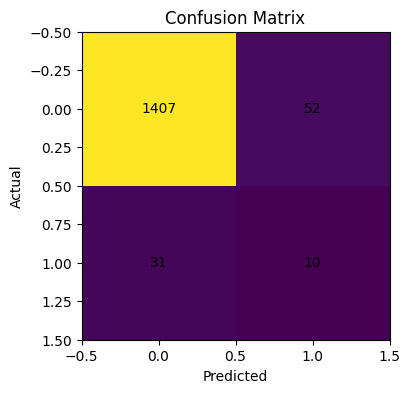

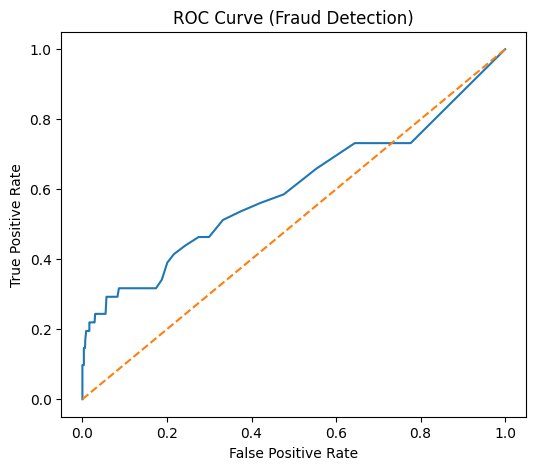

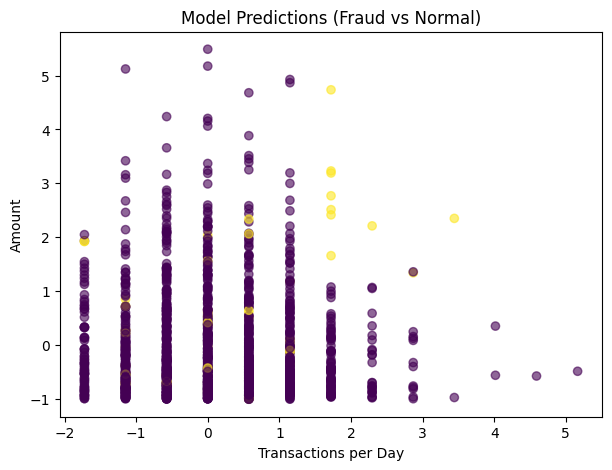

In [1]:
#Fraud Detection using ML Algos

# 1. IMPORT LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.tree import DecisionTreeClassifier

from sklearn.neural_network import MLPClassifier

from imblearn.over_sampling import SMOTE

# 2. GENERATE SYNTHETIC DATASET
np.random.seed(42)

n_samples = 5000

data = pd.DataFrame({
    "amount": np.random.exponential(scale=200, size=n_samples),
    "time": np.random.randint(0, 86400, size=n_samples),
    "location": np.random.randint(1, 50, size=n_samples),
    "transactions_per_day": np.random.poisson(3, size=n_samples)
})

# Fraud pattern (rare class)
data["fraud"] = np.where(
    (data["amount"] > 500) &
    (data["transactions_per_day"] > 5),
    1, 0
)

# Add randomness
data["fraud"] = np.where(np.random.rand(n_samples) < 0.02, 1, data["fraud"])

print("Class Distribution:\n", data["fraud"].value_counts())

# 3. PREPROCESSING
X = data.drop("fraud", axis=1)
y = data["fraud"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

# 4. HANDLE IMBALANCED DATA (SMOTE)
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:\n", pd.Series(y_resampled).value_counts())

# 5. SUPERVISED MODELS
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(32,16), max_iter=300)
}

for name, model in models.items():
    model.fit(X_resampled, y_resampled)
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:,1]

    print(f"\n==== {name} ====")
    print(classification_report(y_test, preds))
    print("ROC-AUC:", roc_auc_score(y_test, probs))

# 6. UNSUPERVISED LEARNING (ANOMALY DETECTION)
iso = IsolationForest(contamination=0.02)
iso.fit(X_train)

anomaly_preds = iso.predict(X_test)
anomaly_preds = np.where(anomaly_preds == -1, 1, 0)

print("\n==== Isolation Forest ====")
print(classification_report(y_test, anomaly_preds))

# 7. AUTOENCODER (SIMPLIFIED USING NN)
autoencoder = MLPClassifier(hidden_layer_sizes=(16,8,16), max_iter=200)
autoencoder.fit(X_train, y_train)

recon_error = np.abs(autoencoder.predict_proba(X_test)[:,1] - y_test)
threshold = np.percentile(recon_error, 95)

auto_preds = (recon_error > threshold).astype(int)

print("\n==== Autoencoder Approximation ====")
print(classification_report(y_test, auto_preds))

# 8. VISUALIZATION (ADVANCED FRAUD DETECTION)

from sklearn.metrics import confusion_matrix, roc_curve

# Use best model (Random Forest)
best_model = RandomForestClassifier(n_estimators=100)
best_model.fit(X_resampled, y_resampled)

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

# 1. CONFUSION MATRIX HEATMAP
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()


# 2. ROC CURVE
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.title("ROC Curve (Fraud Detection)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()


# 3. FRAUD vs NORMAL SCATTER
# Convert back to DataFrame for plotting
X_test_df = pd.DataFrame(X_test, columns=X.columns)

plt.figure(figsize=(7,5))
plt.scatter(
    X_test_df["transactions_per_day"],
    X_test_df["amount"],
    c=y_pred,
    alpha=0.6
)

plt.title("Model Predictions (Fraud vs Normal)")
plt.xlabel("Transactions per Day")
plt.ylabel("Amount")
plt.show()